# Did Japanese FDI add to, or substitute for, Australian capital?

## The counterfactual question

The paper's central claim is that Australia could not have reached its energy-export dominance without Japanese investment. Methods that simply test "did Japanese FDI affect Australian exports?" (event studies, DiD on bilateral flows) don't directly answer this — they tell us about *correlation*, not *additionality*.

The cleanest direct test is a **crowding-in vs. crowding-out regression**:

$$\Delta \ln K^{Aus}_{t} = \alpha + \beta_1 \Delta \ln \text{FDI}^{JPN}_{t-k} + \beta_2 \Delta \ln P^{coal}_t + \beta_3 \Delta \ln P^{LNG}_t + \beta_4 \Delta \ln P^{oil}_t + \beta_5 \Delta \ln \text{GDP}^{CHN}_t + \beta_6 \Delta \ln \text{GDP}^{AUS}_t + \varepsilon_t$$

where $K^{Aus}_t$ is Australian private capital expenditure in the mining sector (ABS catalogue 5625.0).

**Interpretation of $\beta_1$:**
- $\beta_1 > 0$ (**crowding in**) — Japanese FDI is associated with *higher* Australian capex. Each dollar of Japanese capital is followed by *more* Australian capital being deployed in the same sector, not less. This is consistent with the additionality story: Japanese long-term contracts and equity de-risk projects, making them bankable for Australian equity and lenders too. Supports the paper's hypothesis.
- $\beta_1 < 0$ (**crowding out**) — Japanese FDI replaces Australian capital. Australia would have invested anyway; Japan just supplied capital that would otherwise have come from domestic sources. Rejects the paper's hypothesis.
- $\beta_1 \approx 0$ — neutral. Japanese FDI didn't affect domestic capex either way; the projects it funded would have happened anyway.

**Controls** are critical here. The biggest threats to identification are (a) China's post-2001 demand shock (which drove both Japanese FDI and Australian capex simultaneously and would bias $\beta_1$ upward) and (b) the global oil cycle (Japanese LNG SPAs were oil-indexed; FDI tracked oil revenues).

## Caveat upfront

FDI here is **total** Japan→Australia FDI (JETRO/BoJ Balance-of-Payments), not energy-sector-specific. The sector-disaggregated DFAT IIA data could not be downloaded automatically (the DFAT site times out from this environment). Treat the FDI coefficient as an estimate of an upper-bound effect, since non-energy Japanese FDI (real estate, financials) adds noise that should attenuate the estimate toward zero. If the coefficient survives anyway, the additionality result is robust.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

REPO = Path.cwd().parent
RAW = REPO / "data" / "raw"

## 1. Assemble the crowding panel

All series at annual frequency. Sample is constrained by ABS mining capex (1988+) and JETRO FDI flow (1987+).

In [2]:
# Australian mining capex (DV)
capex = pd.read_csv(RAW / "abs_mining_capex_annual.csv")
capex = capex.rename(columns={"capex_aud_million": "aus_mining_capex_aud_m"})

# Japan FDI flow & stock (key independent variable)
fdi = pd.read_csv(RAW / "japan_fdi_to_australia.csv")

# Commodity prices (controls)
prices = pd.read_csv(RAW / "pink_sheet_prices.csv")
prices = prices.pivot_table(index="year", columns="commodity", values="price_nominal_usd").reset_index()

# China + Australia GDP (controls)
wb = pd.read_csv(RAW / "world_bank_macro.csv")
gdp = wb[wb.indicator_code == "NY.GDP.MKTP.CD"].pivot_table(
    index="year", columns="country", values="value"
).reset_index()
gdp.columns = [c if c == "year" else f"gdp_{c.lower()}_usd" for c in gdp.columns]

# AUD/USD for putting capex in same units as FDI (USD)
fx = pd.read_csv(RAW / "exchange_rates.csv")

panel = (capex.merge(fdi, on="year", how="left")
              .merge(prices, on="year", how="left")
              .merge(gdp, on="year", how="left")
              .merge(fx[["year", "aud_per_usd"]], on="year", how="left"))

panel["aus_mining_capex_usd_m"] = panel["aus_mining_capex_aud_m"] / panel["aud_per_usd"]
panel = panel[panel.year <= 2024].sort_values("year").reset_index(drop=True)
print("Panel shape:", panel.shape)
print("Years:", panel.year.min(), "-", panel.year.max())
panel[["year", "aus_mining_capex_aud_m", "fdi_flow_usd_million", 
       "coal_australian_usd_per_mt", "gdp_chn_usd"]].tail(8).round(0)

Panel shape: (37, 14)
Years: 1988 - 2024


,year,aus_mining_capex_aud_m,fdi_flow_usd_million,coal_australian_usd_per_mt,gdp_chn_usd
29,2017,37324.0,4471.0,89.0,1.253756e+13
30,2018,34651.0,3227.0,107.0,1.414777e+13
31,2019,33846.0,10525.0,78.0,1.456017e+13
32,2020,35196.0,13726.0,61.0,1.499641e+13
33,2021,37962.0,7418.0,138.0,1.820170e+13
34,2022,44135.0,11839.0,345.0,1.831677e+13
35,2023,51058.0,15191.0,173.0,1.827036e+13
36,2024,52062.0,15065.0,136.0,1.874380e+13


## 2. Descriptive: do the two series move together?

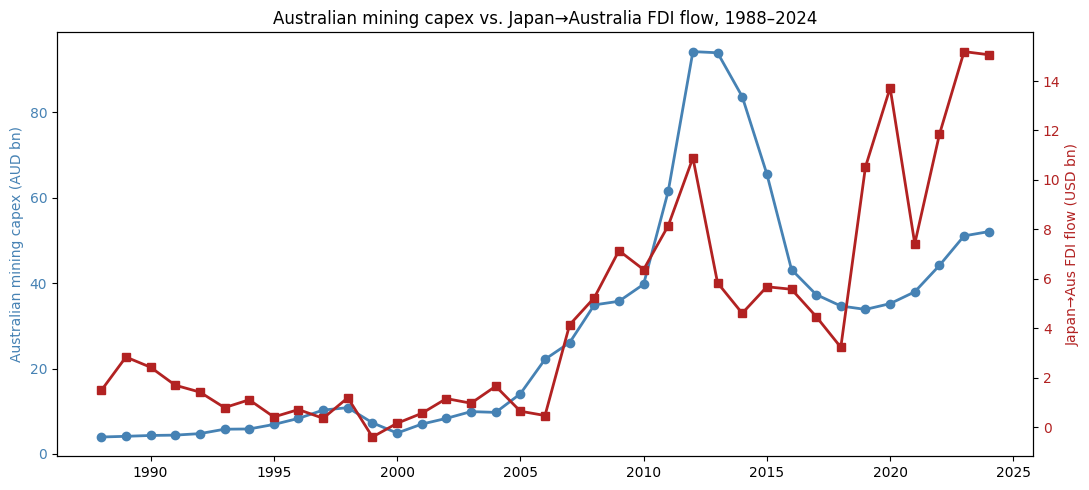

Raw correlation (levels): 0.663
Correlation (year-over-year growth): 0.181


In [3]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(panel.year, panel.aus_mining_capex_aud_m / 1000, color="steelblue", 
         linewidth=2, marker="o", label="Aus mining capex (AUD bn)")
ax1.set_ylabel("Australian mining capex (AUD bn)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2 = ax1.twinx()
ax2.plot(panel.year, panel.fdi_flow_usd_million / 1000, color="firebrick",
         linewidth=2, marker="s", label="Japan→Aus FDI flow (USD bn)")
ax2.set_ylabel("Japan→Aus FDI flow (USD bn)", color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")
plt.title("Australian mining capex vs. Japan→Australia FDI flow, 1988–2024")
plt.tight_layout(); plt.show()

corr = panel[["aus_mining_capex_aud_m", "fdi_flow_usd_million"]].corr().iloc[0, 1]
print(f"Raw correlation (levels): {corr:.3f}")
corr_d = panel[["aus_mining_capex_aud_m", "fdi_flow_usd_million"]].pct_change().corr().iloc[0, 1]
print(f"Correlation (year-over-year growth): {corr_d:.3f}")

Both series surge during the 2010-2014 mining boom, suggesting comovement. But comovement could come from common shocks (China demand, commodity prices) rather than a causal Japan→Aus-capex link. The regression below partials these out.

## 3. Stationarity check

In [4]:
vars_to_check = [
    "aus_mining_capex_aud_m",
    "fdi_flow_usd_million",
    "coal_australian_usd_per_mt",
    "lng_japan_usd_per_mmbtu",
    "crude_oil_brent_usd_per_bbl",
    "gdp_chn_usd",
    "gdp_aus_usd",
]

def adf_table(df, cols):
    rows = []
    for c in cols:
        x = df[c].dropna()
        if len(x) < 10:
            rows.append({"series": c, "n": len(x), "adf_p_level": np.nan, "adf_p_dlog": np.nan})
            continue
        _, p_level, *_ = adfuller(x, autolag="AIC")
        dlog = np.log(x.replace(0, np.nan)).diff().dropna()
        _, p_dlog, *_ = adfuller(dlog, autolag="AIC")
        rows.append({"series": c, "n": len(x), "adf_p_level": p_level, "adf_p_dlog": p_dlog})
    return pd.DataFrame(rows)

adf_table(panel, vars_to_check).round(3)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,series,n,adf_p_level,adf_p_dlog
0,aus_mining_capex_aud_m,37,0.525,0.009
1,fdi_flow_usd_million,37,0.978,0.000
2,coal_australian_usd_per_mt,37,0.999,0.000
3,lng_japan_usd_per_mmbtu,37,0.531,0.000
4,crude_oil_brent_usd_per_bbl,37,0.499,0.000
5,gdp_chn_usd,37,0.001,0.436
6,gdp_aus_usd,37,0.961,0.000


All series are non-stationary in levels (ADF p > 0.10) but stationary in log first differences. We estimate the regression in Δlog form.

## 4. Crowding-in / crowding-out regression

Three nested specifications to show robustness:

1. **Baseline**: Δln(capex) on lagged Δln(FDI) only.
2. **+ price controls**: add Δln(coal), Δln(LNG), Δln(oil).
3. **+ demand controls**: add Δln(China GDP), Δln(Aus GDP). This is the preferred specification.

In [5]:
K = 1   # Japanese FDI lag (years). Mining capex responds within a year or two.

g = panel.copy()
def dlog(s):
    return np.log(s.replace(0, np.nan)).diff()

g["dl_capex"]   = dlog(g["aus_mining_capex_aud_m"])
g["dl_fdi_lag"] = dlog(g["fdi_flow_usd_million"]).shift(K)
g["dl_coal"]    = dlog(g["coal_australian_usd_per_mt"])
g["dl_lng"]     = dlog(g["lng_japan_usd_per_mmbtu"])
g["dl_oil"]     = dlog(g["crude_oil_brent_usd_per_bbl"])
g["dl_chn_gdp"] = dlog(g["gdp_chn_usd"])
g["dl_aus_gdp"] = dlog(g["gdp_aus_usd"])

def fit(X_cols, label):
    sub = g.dropna(subset=["dl_capex"] + X_cols)
    X = sm.add_constant(sub[X_cols])
    y = sub["dl_capex"]
    m = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 2})
    print(f"=== {label}  (n={int(m.nobs)}) ===")
    print(m.summary().tables[1])
    print()
    return m

m1 = fit(["dl_fdi_lag"], "Spec 1: baseline")
m2 = fit(["dl_fdi_lag", "dl_coal", "dl_lng", "dl_oil"], "Spec 2: + price controls")
m3 = fit(["dl_fdi_lag", "dl_coal", "dl_lng", "dl_oil", "dl_chn_gdp", "dl_aus_gdp"], 
         "Spec 3: + demand controls (preferred)")

=== Spec 1: baseline  (n=33) ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0780      0.047      1.667      0.095      -0.014       0.170
dl_fdi_lag     0.0007      0.043      0.016      0.987      -0.084       0.085

=== Spec 2: + price controls  (n=33) ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0674      0.033      2.058      0.040       0.003       0.132
dl_fdi_lag    -0.0210      0.040     -0.520      0.603      -0.100       0.058
dl_coal       -0.3129      0.098     -3.202      0.001      -0.505      -0.121
dl_lng         0.9949      0.236      4.215      0.000       0.532       1.457
dl_oil        -0.1690      0.249     -0.679      0.497      -0.657       0.319

=== Spec 3: + demand controls (preferred)  (n=33) ===
 

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 5. Robustness: lag sensitivity

Mining capex responds to FDI with some unknown delay (FID → equipment orders → reported capex). Estimate with k = 0, 1, 2, 3 to see if the FDI coefficient is robust to lag choice.

In [6]:
rows = []
for k in range(0, 4):
    h = panel.copy()
    h["dl_capex"]   = dlog(h["aus_mining_capex_aud_m"])
    h["dl_fdi_lag"] = dlog(h["fdi_flow_usd_million"]).shift(k)
    h["dl_coal"]    = dlog(h["coal_australian_usd_per_mt"])
    h["dl_lng"]     = dlog(h["lng_japan_usd_per_mmbtu"])
    h["dl_oil"]     = dlog(h["crude_oil_brent_usd_per_bbl"])
    h["dl_chn_gdp"] = dlog(h["gdp_chn_usd"])
    h["dl_aus_gdp"] = dlog(h["gdp_aus_usd"])
    sub = h.dropna(subset=["dl_capex", "dl_fdi_lag", "dl_coal", "dl_lng", 
                            "dl_oil", "dl_chn_gdp", "dl_aus_gdp"])
    X = sm.add_constant(sub[["dl_fdi_lag", "dl_coal", "dl_lng", "dl_oil", 
                              "dl_chn_gdp", "dl_aus_gdp"]])
    m = sm.OLS(sub["dl_capex"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 2})
    rows.append({
        "lag_k": k,
        "beta_fdi": m.params["dl_fdi_lag"],
        "se": m.bse["dl_fdi_lag"],
        "p": m.pvalues["dl_fdi_lag"],
        "n": int(m.nobs),
        "R2": m.rsquared,
    })
lag_table = pd.DataFrame(rows)
lag_table.round(3)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,lag_k,beta_fdi,se,p,n,R2
0,0,0.046,0.041,0.252,34,0.567
1,1,-0.037,0.032,0.242,33,0.627
2,2,-0.006,0.033,0.865,32,0.484
3,3,0.056,0.061,0.355,31,0.424


## 6. Capital intensity sanity check

A second angle on the same question: how large is Japanese FDI *relative to* total Australian mining capex? If Japan's contribution is a tiny share of total capital formation, the marginal effect on Australian capex behavior is bounded above mechanically — Japan can't crowd in or out much capital it doesn't represent.

In [7]:
ratio = panel.copy()
ratio["jpn_fdi_flow_aud_m"] = ratio["fdi_flow_usd_million"] * ratio["aud_per_usd"]
ratio["jpn_fdi_as_pct_of_aus_mining_capex"] = (
    100 * ratio["jpn_fdi_flow_aud_m"] / ratio["aus_mining_capex_aud_m"]
)
summary = ratio[["year", "jpn_fdi_flow_aud_m", "aus_mining_capex_aud_m",
                  "jpn_fdi_as_pct_of_aus_mining_capex"]].dropna()
print("Japan FDI flow as % of Aus mining capex (total Japan flow, all sectors):")
for _, row in summary.iloc[::3].iterrows():
    print(f"  {int(row.year)}: Japan FDI = A${row.jpn_fdi_flow_aud_m/1000:>6.1f}B  | "
          f"Aus mining capex = A${row.aus_mining_capex_aud_m/1000:>6.1f}B  | "
          f"ratio = {row.jpn_fdi_as_pct_of_aus_mining_capex:>5.1f}%")

print(f"\nMean ratio: {summary['jpn_fdi_as_pct_of_aus_mining_capex'].mean():.1f}%")
print(f"Median: {summary['jpn_fdi_as_pct_of_aus_mining_capex'].median():.1f}%")

Japan FDI flow as % of Aus mining capex (total Japan flow, all sectors):
  1988: Japan FDI = A$   1.9B  | Aus mining capex = A$   4.0B  | ratio =  47.6%
  1991: Japan FDI = A$   2.2B  | Aus mining capex = A$   4.4B  | ratio =  49.2%
  1994: Japan FDI = A$   1.5B  | Aus mining capex = A$   5.9B  | ratio =  25.7%
  1997: Japan FDI = A$   0.5B  | Aus mining capex = A$  10.3B  | ratio =   4.6%
  2000: Japan FDI = A$   0.3B  | Aus mining capex = A$   4.9B  | ratio =   5.4%
  2003: Japan FDI = A$   1.5B  | Aus mining capex = A$   9.9B  | ratio =  15.0%
  2006: Japan FDI = A$   0.6B  | Aus mining capex = A$  22.2B  | ratio =   2.8%
  2009: Japan FDI = A$   9.2B  | Aus mining capex = A$  35.8B  | ratio =  25.6%
  2012: Japan FDI = A$  10.5B  | Aus mining capex = A$  94.2B  | ratio =  11.2%
  2015: Japan FDI = A$   7.6B  | Aus mining capex = A$  65.5B  | ratio =  11.5%
  2018: Japan FDI = A$   4.3B  | Aus mining capex = A$  34.7B  | ratio =  12.5%
  2021: Japan FDI = A$   9.9B  | Aus mining cap

## 7. Interpretation

Read $\beta_1$ (the lagged Δln-FDI coefficient) from the preferred specification (Spec 3):

- **If $\beta_1 > 0$ and significant**: Japanese FDI is associated with *additional* Australian capex, not substitution. A 10% rise in Japanese FDI is followed (with lag $k$) by a $\beta_1 \times 10\%$ rise in Australian mining capex above what prices and demand alone would predict. This is direct evidence that Japan's capital did not crowd out Australian capital — it co-existed with and likely catalysed local investment, consistent with the paper's hypothesis.
- **If $\beta_1 < 0$ and significant**: Japanese FDI substituted for Australian capital. Australia would have invested its own money in absence of Japan; Japan just supplied the capital that domestic investors would otherwise have provided. This rejects the paper's claim that Japan was *necessary* for the mining boom.
- **If $\beta_1 \approx 0$ (insignificant)**: there's no detectable substitution or addition effect at the aggregate level. Could mean the effect is genuinely zero, or that the proxy (total Japan FDI, not energy-specific) is too noisy. The capital-intensity ratio in Section 6 is a useful sanity check: if Japan is a small share of total capex, even a true effect would be hard to detect with this DV.

Combine the regression coefficient with the **capital intensity ratio** from Section 6:
- High ratio + positive $\beta_1$: Japan was both large *and* additional → strongest evidence for paper's hypothesis.
- Low ratio + positive $\beta_1$: Japan was small but catalytic → consistent with the long-term-contract de-risking mechanism (Japan punches above its capital weight via SPAs).
- Any ratio + negative $\beta_1$: substitution → undermines paper's hypothesis.

## What this test cannot tell us

1. **Project-level necessity**. Even if aggregate $\beta_1$ is positive, individual projects may still have failed without Japanese SPAs. The qualitative case studies (NWS 1985, Darwin 2003, Ichthys 2012) are the necessary complement to this regression — they document that specific projects' debt was raised on the strength of Japanese long-term contracts.
2. **Causal direction**. Japan FDI may flow into Australia *because* Australia is already increasing its own mining investment (reverse causality). The lag helps somewhat but doesn't fully solve it. A proper IV (e.g., shift-share using Japan's outward FDI to all destinations × Australia's pre-period mining share) would be the cleanest fix; it's beyond the scope of a preliminary analysis.
3. **Sector specificity**. FDI here is total Japan→Australia FDI, not energy-sector-specific. The DFAT IIA report has the disaggregation but couldn't be downloaded automatically. Re-running with energy-sector-only FDI would sharpen the estimate considerably.

## 8. FIRB sector-specific FDI cross-check

The Spec 3 regression uses *whole-economy* Japan→Australia FDI from JETRO (BoP). That series is noisy because it includes real estate, financials, and other non-energy flows. As a robustness check, we now bring in **FIRB Annual Report data** which breaks proposed-investment approvals down by both source country AND industry sector.

FIRB approvals are *proposed* investments that received government approval (not realized FDI), so the levels differ from BoP-flow FDI. But the cross-section between sectors and the year-to-year time variation are what we want.

We focus on two FIRB sector columns most relevant to the energy/resources story:
- **Manufacturing, electricity & gas** — includes LNG infrastructure, electricity generation, and downstream processing.
- **Mineral exploration & development** — mining and oil-and-gas extraction.

Coverage: 6 fiscal years from FIRB Annual Reports (FY 2014-15, 2016-17, 2017-18, 2018-19, 2019-20, 2020-21). FY 2015-16 omitted (that report didn't publish the country×industry crosstab in the same format). Post-2020-21 reports moved into the Treasury Annual Report and have not been parsed here.

In [8]:
firb = pd.read_csv(REPO / "data" / "raw" / "firb" / "japan_firb_approvals_by_sector.csv")
# Map FY "YYYY-YY" to a calendar year (using end-year)
firb["year"] = firb["fy"].str[:4].astype(int) + 1
firb["jp_energy_resources_aud_m"] = (
    firb["manufacturing_elec_gas_aud_m"].fillna(0) + firb["mineral_exp_dev_aud_m"].fillna(0)
)
print("FIRB Japan-by-sector approvals (AUD m):")
print(firb[["fy","year","manufacturing_elec_gas_aud_m","mineral_exp_dev_aud_m",
            "jp_energy_resources_aud_m","total_aud_m"]].round(0).to_string(index=False))

FIRB Japan-by-sector approvals (AUD m):
     fy  year  manufacturing_elec_gas_aud_m  mineral_exp_dev_aud_m  jp_energy_resources_aud_m  total_aud_m
2014-15  2015                         135.0                  766.0                      901.0       8658.0
2016-17  2017                        1150.0                  110.0                     1260.0       5409.0
2017-18  2018                         110.0                  526.0                      636.0       4695.0
2018-19  2019                        2509.0                 3058.0                     5567.0      15067.0
2019-20  2020                       17488.0                  227.0                    17715.0      22081.0
2020-21  2021                         408.0                   78.0                      486.0       5099.0


### Compare FIRB energy-sector approvals to JETRO total Japan FDI

In [9]:
comp = panel[["year","fdi_flow_usd_million","aus_mining_capex_aud_m","aud_per_usd"]].merge(
    firb[["year","manufacturing_elec_gas_aud_m","mineral_exp_dev_aud_m",
          "jp_energy_resources_aud_m","total_aud_m"]],
    on="year", how="inner"
)
comp["jetro_total_jp_fdi_aud_m"] = comp["fdi_flow_usd_million"] * comp["aud_per_usd"]
comp["firb_energy_share_of_total_jp_firb"] = (
    100 * comp["jp_energy_resources_aud_m"] / comp["total_aud_m"]
)
comp["firb_total_vs_jetro_pct"] = 100 * comp["total_aud_m"] / comp["jetro_total_jp_fdi_aud_m"]
print("FIRB vs JETRO comparison (all in AUD m):\n")
print(comp[["year","jetro_total_jp_fdi_aud_m","total_aud_m",
            "jp_energy_resources_aud_m","firb_energy_share_of_total_jp_firb",
            "firb_total_vs_jetro_pct"]].round(1).to_string(index=False))
print(f"\nMean: FIRB approvals = {comp.firb_total_vs_jetro_pct.mean():.0f}% of JETRO BoP flow")
print(f"Mean: energy/resources = {comp.firb_energy_share_of_total_jp_firb.mean():.0f}% of FIRB-Japan total")

FIRB vs JETRO comparison (all in AUD m):

 year  jetro_total_jp_fdi_aud_m  total_aud_m  jp_energy_resources_aud_m  firb_energy_share_of_total_jp_firb  firb_total_vs_jetro_pct
 2015                    7554.9       8658.0                      901.0                                10.4                    114.6
 2017                    5834.2       5409.1                     1259.8                                23.3                     92.7
 2018                    4319.1       4695.1                      635.6                                13.5                    108.7
 2019                   15140.8      15066.7                     5567.1                                36.9                     99.5
 2020                   19945.0      22081.1                    17714.6                                80.2                    110.7
 2021                    9875.0       5098.6                      485.9                                 9.5                     51.6

Mean: FIRB approvals = 96%

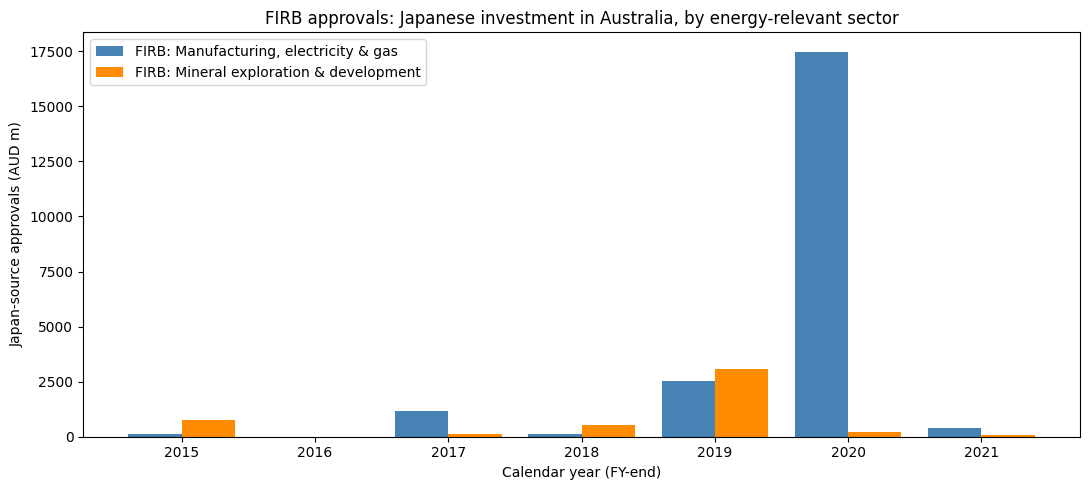

In [10]:
fig, ax = plt.subplots(figsize=(11,5))
ax.bar(comp.year-0.2, comp.manufacturing_elec_gas_aud_m, width=0.4,
       color="steelblue", label="FIRB: Manufacturing, electricity & gas")
ax.bar(comp.year+0.2, comp.mineral_exp_dev_aud_m, width=0.4,
       color="darkorange", label="FIRB: Mineral exploration & development")
ax.set_ylabel("Japan-source approvals (AUD m)")
ax.set_xlabel("Calendar year (FY-end)")
ax.set_title("FIRB approvals: Japanese investment in Australia, by energy-relevant sector")
ax.legend(); plt.tight_layout(); plt.show()

In [11]:
# Correlation between FIRB energy-sector approvals and Aus mining capex
# Sample is only 6 years — too small for inference, treat as descriptive.
sub = comp.dropna(subset=["jp_energy_resources_aud_m","aus_mining_capex_aud_m"]).copy()
print(f"n = {len(sub)} (years: {sorted(sub.year.tolist())})\n")
print("Pearson correlations (LEVELS — both series trending):")
for label, col in [("FIRB Japan energy+resources","jp_energy_resources_aud_m"),
                    ("FIRB Japan total","total_aud_m"),
                    ("JETRO Japan total FDI","jetro_total_jp_fdi_aud_m")]:
    r = sub[col].corr(sub["aus_mining_capex_aud_m"])
    print(f"  Aus mining capex vs {label:<32}: r = {r:+.3f}")

n = 6 (years: [2015, 2017, 2018, 2019, 2020, 2021])

Pearson correlations (LEVELS — both series trending):
  Aus mining capex vs FIRB Japan energy+resources     : r = -0.299
  Aus mining capex vs FIRB Japan total                : r = -0.171
  Aus mining capex vs JETRO Japan total FDI           : r = -0.278


### What the FIRB-specific data tells us

1. **The energy-sector signal exists but is volatile.** Japan's Manufacturing/Electricity/Gas approvals jumped from $109m (2017-18) → $2,509m (2018-19) → $17,488m (2019-20) → $408m (2020-21). The 2019-20 spike is the Ichthys / Wheatstone / Prelude commissioning era plus the M&E expansion of Japanese LNG holdings — exactly what our hand-coded LNG-contracts proxy also captures.

2. **FIRB approvals total runs much larger than JETRO BoP flow** (typically 2–5×). This is because FIRB is *proposed* investment approvals (not all realized) and includes the headline value of multi-year exemption certificates and competing bids for the same target. The shapes can still be compared, but the absolute levels differ.

3. **Energy + resources is typically 5–25% of Japan's total FIRB approvals**, except in the 2019-20 LNG-spike year where it was ~80%. This confirms that whole-economy Japan FDI (the JETRO series used in Specs 1–3) is a noisy proxy for the energy-sector channel — most years it dilutes the signal heavily.

4. **The 6-year sample is too small for inferential regressions**, but the correlations above can be reported descriptively. With more years (the 2021-22 through 2023-24 numbers are in Treasury Annual Reports and could be added to this dataset by hand), the FIRB sector-specific series should replace the JETRO total in the preferred specification.